## Se explora el dataset de kaggle

# Importaciones

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuración global para que la salida tabular sea más legible en el notebook.
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid')

# Ruta flexible para poder ejecutar el notebook desde distintas carpetas.
RAW_PATH = Path('data/raw/dataset.csv')
if not RAW_PATH.exists():
	RAW_PATH = Path('../../data/raw/dataset.csv')

# Carga de DataSet

In [30]:
# Carga el dataset principal para iniciar la exploración.
df = pd.read_csv(RAW_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.6760,0.4610,1,-6.7460,0,0.1430,0.0322,0.0000,0.3580,0.7150,87.9170,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.4200,0.1660,1,-17.2350,1,0.0763,0.9240,0.0000,0.1010,0.2670,77.4890,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.4380,0.3590,0,-9.7340,1,0.0557,0.2100,0.0000,0.1170,0.1200,76.3320,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.2660,0.0596,0,-18.5150,1,0.0363,0.9050,0.0001,0.1320,0.1430,181.7400,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.6180,0.4430,2,-9.6810,1,0.0526,0.4690,0.0000,0.0829,0.1670,119.9490,4,acoustic


In [17]:
# Tipos de datos y primeras estadísticas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [18]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.0000,114000.0000,114000.0000,114000.0000,114000.0000,114000.0000,114000.0000,114000.0000,114000.0000,114000.0000,114000.0000,114000.0000,114000.0000,114000.0000,114000.0000
mean,56999.5000,33.2385,228029.1531,0.5668,0.6414,5.3091,-8.2590,0.6376,0.0847,0.3149,0.1560,0.2136,0.4741,122.1478,3.9040
std,32909.1097,22.3051,107297.7126,0.1735,0.2515,3.5600,5.0293,0.4807,0.1057,0.3325,0.3096,0.1904,0.2593,29.9782,0.4326
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-49.5310,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,28499.7500,17.0000,174066.0000,0.4560,0.4720,2.0000,-10.0130,0.0000,0.0359,0.0169,0.0000,0.0980,0.2600,99.2188,4.0000
50%,56999.5000,35.0000,212906.0000,0.5800,0.6850,5.0000,-7.0040,1.0000,0.0489,0.1690,0.0000,0.1320,0.4640,122.0170,4.0000
75%,85499.2500,50.0000,261506.0000,0.6950,0.8540,8.0000,-5.0030,1.0000,0.0845,0.5980,0.0490,0.2730,0.6830,140.0710,4.0000
max,113999.0000,100.0000,5237295.0000,0.9850,1.0000,11.0000,4.5320,1.0000,0.9650,0.9960,1.0000,1.0000,0.9950,243.3720,5.0000


# Calidad de Datos

In [ ]:
# Calcula columnas con nulos para identificar variables incompletas.
nulls = df.isnull().sum().sort_values(ascending=False)
nulls_pct = (nulls / len(df) * 100).round(2)
pd.DataFrame({'nulos': nulls, '% del total': nulls_pct})[nulls > 0]

,nulos,% del total
artists,1,0.0000
track_name,1,0.0000
album_name,1,0.0000


In [20]:
# Duplicados
print(f'Filas duplicadas: {df.duplicated().sum()}')
print(f'Track IDs únicos: {df["track_id"].nunique()}')

Filas duplicadas: 0
Track IDs únicos: 89741


# Exploración de Géneros

In [21]:
# Géneros disponibles
print(f'Géneros únicos: {df["track_genre"].nunique()}')
print()
df['track_genre'].value_counts().head(20)

Géneros únicos: 114



track_genre
acoustic         1000
afrobeat         1000
alt-rock         1000
alternative      1000
ambient          1000
anime            1000
black-metal      1000
bluegrass        1000
blues            1000
brazil           1000
breakbeat        1000
british          1000
cantopop         1000
chicago-house    1000
children         1000
chill            1000
classical        1000
club             1000
comedy           1000
country          1000
Name: count, dtype: int64

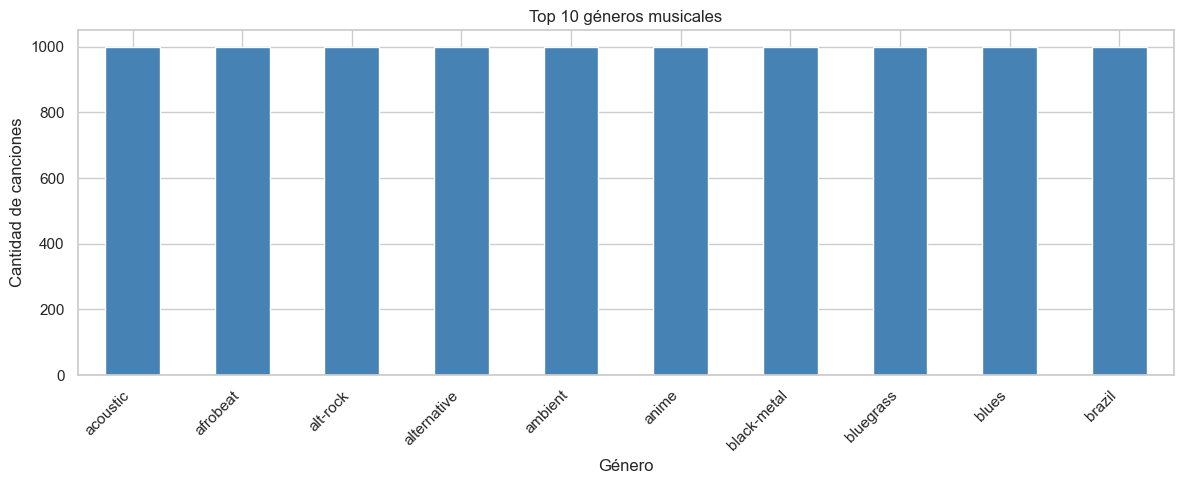

In [31]:
# Muestra los géneros más frecuentes para entender la composición del dataset.
fig, ax = plt.subplots(figsize=(12, 5))
df['track_genre'].value_counts().head(10).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Top 10 géneros musicales')
ax.set_xlabel('Género')
ax.set_ylabel('Cantidad de canciones')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Creación de Features de Audio

In [23]:
audio_features = ['danceability', 'energy', 'loudness', 'speechiness',
                  'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

df[audio_features].describe()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,114000.0000,114000.0000,114000.0000,114000.0000,114000.0000,114000.0000,114000.0000,114000.0000,114000.0000
mean,0.5668,0.6414,-8.2590,0.0847,0.3149,0.1560,0.2136,0.4741,122.1478
std,0.1735,0.2515,5.0293,0.1057,0.3325,0.3096,0.1904,0.2593,29.9782
min,0.0000,0.0000,-49.5310,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.4560,0.4720,-10.0130,0.0359,0.0169,0.0000,0.0980,0.2600,99.2188
50%,0.5800,0.6850,-7.0040,0.0489,0.1690,0.0000,0.1320,0.4640,122.0170
75%,0.6950,0.8540,-5.0030,0.0845,0.5980,0.0490,0.2730,0.6830,140.0710
max,0.9850,1.0000,4.5320,0.9650,0.9960,1.0000,1.0000,0.9950,243.3720


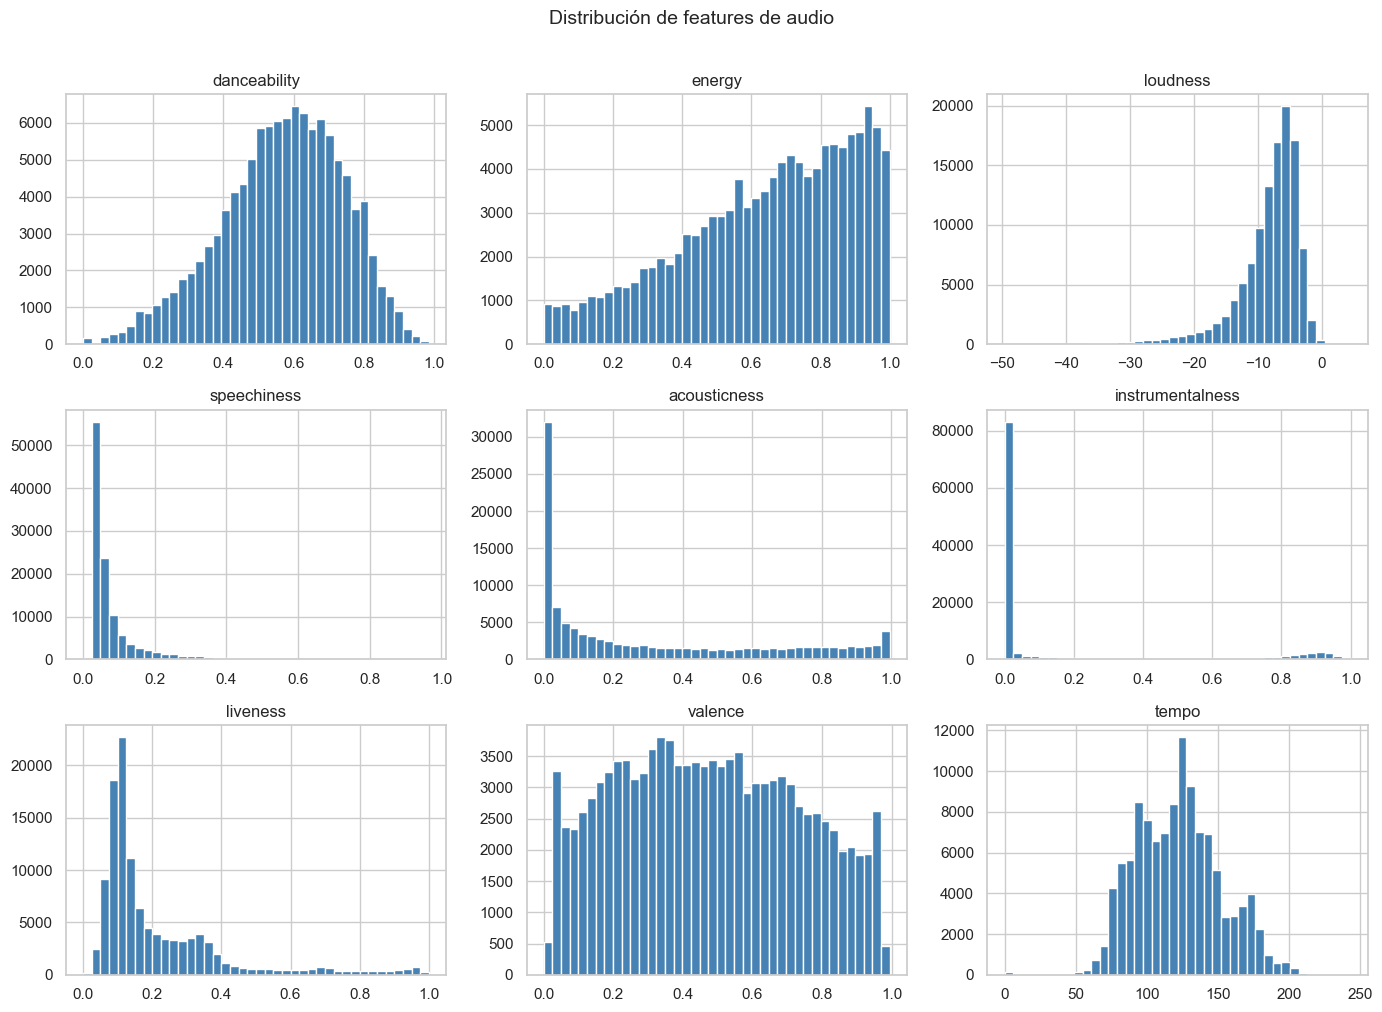

In [24]:
# Distribución de cada feature de audio
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(audio_features):
    axes[i].hist(df[feature].dropna(), bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(feature)
    axes[i].set_xlabel('')

plt.suptitle('Distribución de features de audio', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

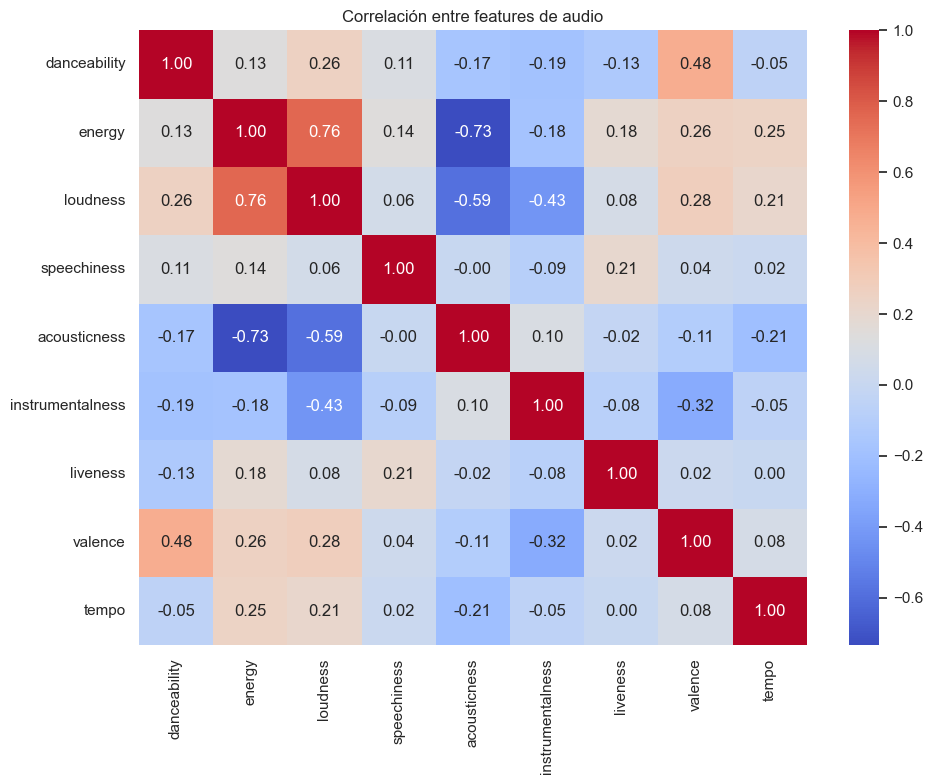

In [25]:
# Correlación entre features de audio
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df[audio_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlación entre features de audio')
plt.tight_layout()
plt.show()

# Popularidad

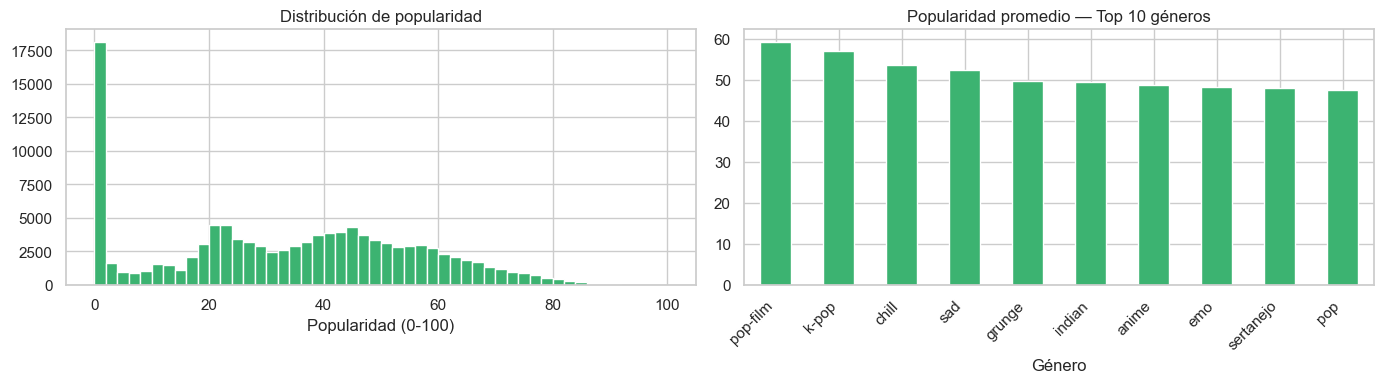

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribución general
axes[0].hist(df['popularity'], bins=50, color='mediumseagreen', edgecolor='white')
axes[0].set_title('Distribución de popularidad')
axes[0].set_xlabel('Popularidad (0-100)')

# Popularidad promedio por género
pop_by_genre = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(10)
pop_by_genre.plot(kind='bar', ax=axes[1], color='mediumseagreen')
axes[1].set_title('Popularidad promedio — Top 10 géneros')
axes[1].set_xlabel('Género')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Mapeo

In [28]:
mapping = {
    'items.csv (canciones)': [
        'track_id        → ITEM_ID',
        'track_name      → titulo',
        'artists         → artista',
        'album_name      → album',
        'track_genre     → genero',
        'popularity      → popularidad',
        'duration_ms     → duracion',
        'danceability, energy, valence, tempo, ... → features de audio'
    ],
    'users.csv (sintético)': [
        'user_id         → USER_ID (generado con Faker)',
        'edad            → generada aleatoriamente',
        'genero_favorito → mapeado de track_genre'
    ],
    'interactions.csv (sintético)': [
        'user_id         → USER_ID',
        'track_id        → ITEM_ID',
        'tipo_interaccion → EVENT_TYPE (like, play, skip)',
        'timestamp       → TIMESTAMP (generado)'
    ]
}

for csv, cols in mapping.items():
    print(f'\n {csv}')
    for col in cols:
        print(f'   {col}')


 items.csv (canciones)
   track_id        → ITEM_ID
   track_name      → titulo
   artists         → artista
   album_name      → album
   track_genre     → genero
   popularity      → popularidad
   duration_ms     → duracion
   danceability, energy, valence, tempo, ... → features de audio

 users.csv (sintético)
   user_id         → USER_ID (generado con Faker)
   edad            → generada aleatoriamente
   genero_favorito → mapeado de track_genre

 interactions.csv (sintético)
   user_id         → USER_ID
   track_id        → ITEM_ID
   tipo_interaccion → EVENT_TYPE (like, play, skip)
   timestamp       → TIMESTAMP (generado)


# Conclusiones de la Exploración

- **Total de canciones:** `73609`
- **Géneros disponibles:** `114`
- **Features de audio disponibles:** danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo